In [18]:
import pandas as pd
df = pd.read_csv('Train.csv')
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [19]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [20]:
df = df.drop('Work_Experience', axis=1)

In [21]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Spending_Score,0
Family_Size,335
Var_1,76
Segmentation,0


In [22]:
df['Profession'] = df['Profession'].fillna('Unknown')

In [23]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,0
Spending_Score,0
Family_Size,335
Var_1,76
Segmentation,0


In [24]:
mode_graduated = df['Graduated'].mode()[0]
df['Graduated'] = df['Graduated'].fillna(mode_graduated)
print(f"Missing values in 'Graduated' filled with the mode: {mode_graduated}")

df.isnull().sum()

Missing values in 'Graduated' filled with the mode: Yes


,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,0
Profession,0
Spending_Score,0
Family_Size,335
Var_1,76
Segmentation,0


In [25]:
df.drop('Family_Size', axis=1, inplace=True)


In [26]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,0
Profession,0
Spending_Score,0
Var_1,76
Segmentation,0


In [27]:
mode_value =df['Ever_Married'].mode()[0]
df["Ever_Married"] = df["Ever_Married"].fillna(mode_value)
df.loc[(df['Ever_Married'].isna()) & (df['Age'] < 18), 'Ever_Married'] = 'No'
# print(f"Missing values in 'Ever_Married' filled with the mode: {mode_value}")

In [28]:
df['Ever_Married']

,Ever_Married
0,No
1,Yes
2,Yes
3,Yes
4,Yes
...,...
8063,No
8064,No
8065,No
8066,No


In [29]:
df = df.drop('Var_1', axis=1)

In [30]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Spending_Score,0
Segmentation,0


In [31]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])
df['Profession'] = label_encoder.fit_transform(df['Profession'])
df['Graduated'] = label_encoder.fit_transform(df['Graduated'])
df['Spending_Score'] = label_encoder.fit_transform(df['Spending_Score'])
df['Segmentation'] = label_encoder.fit_transform(df['Segmentation'])
df['Ever_Married'] = label_encoder.fit_transform(df['Ever_Married'])


In [32]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Spending_Score,Segmentation
0,462809,1,0,22,0,5,2,3
1,462643,0,1,38,1,2,0,0
2,466315,0,1,67,1,2,2,1
3,461735,1,1,67,1,7,1,1
4,462669,0,1,40,1,3,1,0


In [33]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Spending_Score,Segmentation
0,462809,1,0,22,0,5,2,3
1,462643,0,1,38,1,2,0,0
2,466315,0,1,67,1,2,2,1
3,461735,1,1,67,1,7,1,1
4,462669,0,1,40,1,3,1,0


In [36]:
from sklearn.model_selection import train_test_split

X = df.drop('Segmentation', axis=1)
y = df['Segmentation']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print("training data:")
print(X_train)
print(y_train)

(6454, 7)
(1614, 7)
(6454,)
(1614,)
training data:
          ID  Gender  Ever_Married  Age  Graduated  Profession  Spending_Score
2821  460591       0             1   38          1           1               2
6192  460459       0             0   33          0           2               2
1393  459043       0             1   49          0           2               2
812   461220       0             0   26          0           4               2
2215  460403       0             0   56          1           1               2
...      ...     ...           ...  ...        ...         ...             ...
5226  460386       1             1   29          1           5               2
5390  461514       1             0   31          0           5               2
860   467236       0             0   40          1           7               2
7603  460278       1             1   29          1           0               2
7270  460267       0             0   27          1           5               2



In [42]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Spending_Score,0
Segmentation,0


In [49]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_train)
# print(clusters


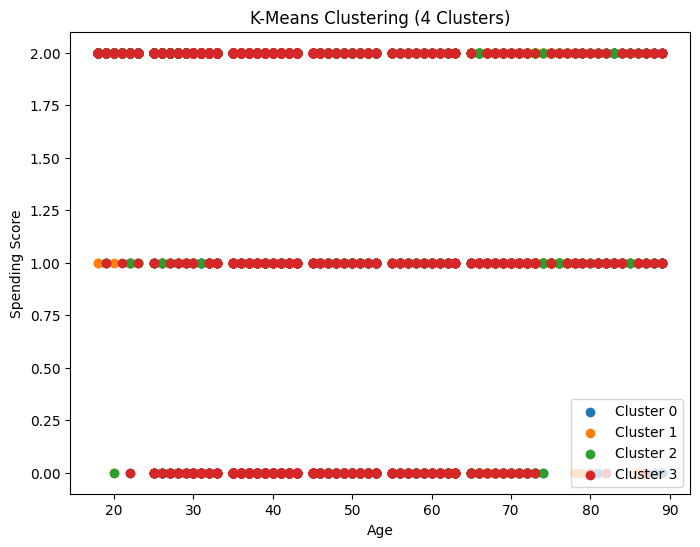

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i in range(4):
    plt.scatter(
        X_train[clusters == i]['Age'],
        X_train[clusters == i]['Spending_Score'],
        label=f'Cluster {i}'
    )

plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.title('K-Means Clustering (4 Clusters)')
plt.legend()
plt.show()

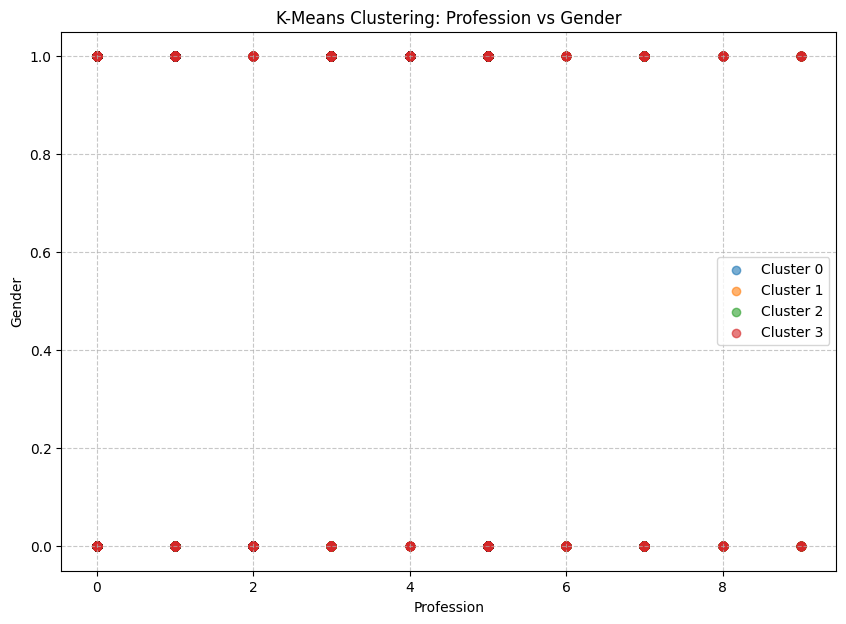

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Create a list of features to plot
feature_x = 'Profession'
feature_y = 'Gender'

for i in range(4):
    plt.scatter(
        X_train[clusters == i][feature_x],
        X_train[clusters == i][feature_y],
        label=f'Cluster {i}',
        alpha=0.6
    )

plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title(f'K-Means Clustering: {feature_x} vs {feature_y}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [57]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_train)
# print(clusters

X_train['Cluster'] = clusters


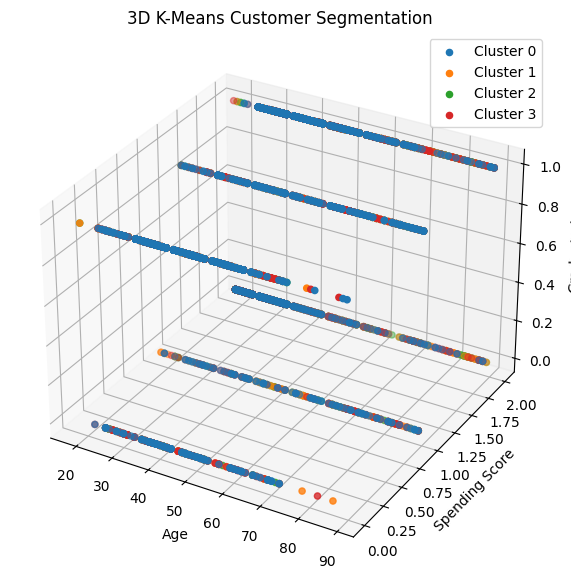

In [59]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

for i in range(4):
    cluster_data = X_train[X_train['Cluster'] == i]
    ax.scatter(
        cluster_data['Age'],
        cluster_data['Spending_Score'],
        cluster_data['Graduated'],
        label=f'Cluster {i}'
    )

ax.set_xlabel('Age')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Graduated')
ax.set_title('3D K-Means Customer Segmentation')
ax.legend()
plt.show()


In [54]:
submission = pd.DataFrame({'ID': X_train['ID'], 'Segmentation': clusters})
submission.to_csv('submission.csv', index=False)

| Cluster | Interpretation                |
| ------- | ----------------------------- |
| 0       | Young, high spenders          |
| 1       | Older, low spenders           |
| 2       | Middle-aged, average spenders |
| 3       | Young, low spenders           |
